# AgriSense — Task 1: Data Acquisition & Radiometric Pre-Processing

**Pipeline:** `S2_SR (BOA)` → `Cloud Masking (s2cloudless)` → `Co-registration (SIFT+RANSAC)` → `Final GeoTIFF`

**Benchmark:** `TOA → DOS-1` vs `BOA (Sen2Cor reference)` → `PSNR/SSIM table`

**Study area:** Punjab, Pakistan | AOI: 73.0–73.5°E, 30.5–31.0°N | CRS: EPSG:32642

**Season:** Rabi 2023–2024 (Oct 2023 – Apr 2024)

In [2]:
# ─── Install / verify dependencies ───────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['rasterio', 's2cloudless', 'scikit-image', 'opencv-contrib-python',
            'matplotlib', 'numpy', 'scikit-learn']:
    try:
        __import__(pkg.replace('-', '_').replace('contrib_python', 'cv2'))
    except ImportError:
        print(f'Installing {pkg}...')
        pip_install(pkg)

print('All dependencies ready.')

Installing scikit-image...
Installing opencv-contrib-python...
Installing scikit-learn...
All dependencies ready.


In [2]:
# ─── Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import rasterio
import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

# ─── File paths (adjust if needed) ───────────────────────────────────────────
BASE_DIR     = Path('/content/drive/MyDrive/AgriSense')   # folder where your GeoTIFFs are stored
BOA_PATH     = BASE_DIR / 'S2_BOA_Punjab_Rabi2023.tif'
TOA_PATH     = BASE_DIR / 'S2_TOA_Punjab_Rabi2023.tif'
CLOUD1_PATH  = BASE_DIR / 'S2_CloudBands_Date1.tif'
SIFT1_PATH   = BASE_DIR / 'S2_SIFT_Date1.tif'
SIFT2_PATH   = BASE_DIR / 'S2_SIFT_Date2.tif'

BAND_SHORT   = ['B2','B3','B4','B5','B8','B11','B12']
BAND_NAMES   = ['B2 Blue','B3 Green','B4 Red','B5 RedEdge','B8 NIR','B11 SWIR1','B12 SWIR2']
ESUN = {'B2':1959.66,'B3':1823.24,'B4':1512.79,'B5':1425.56,'B8':1041.63,'B11':245.59,'B12':85.25}

print('Setup complete.')

Setup complete.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 — Load BOA Product (Main)

In [5]:
# Load and scale: S2_SR exports DN 0–10000; multiply by 0.0001 for reflectance [0,1]
with rasterio.open("/content/drive/MyDrive/AgriSense/S2_BOA_Punjab_Rabi2023.tif") as src:
    boa_array   = src.read().astype(np.float32) * 0.0001
    boa_profile = src.profile.copy()
    boa_crs     = src.crs

print(f'BOA array shape : {boa_array.shape}  (bands, H, W)')
print(f'CRS             : {boa_crs}')
print(
    f'Reflectance range: '
    f'[{np.nanmin(boa_array):.4f}, {np.nanmax(boa_array):.4f}]'
)

BOA array shape : (7, 5731, 5003)  (bands, H, W)
CRS             : EPSG:32642
Reflectance range: [0.0168, 0.8314]


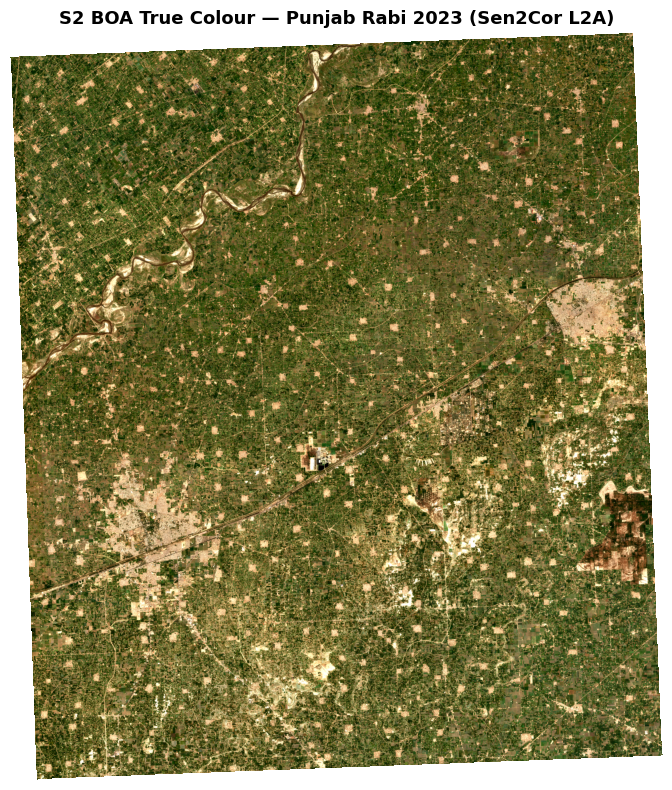

Saved: fig_boa_truecolour.png


In [26]:
# ── Visualise True-Colour composite (B4=R, B3=G, B2=B) ──────────────────────
def percentile_stretch(r, g, b, pct=2):
    rgb = np.stack([r, g, b], axis=-1).astype(np.float32)
    lo, hi = np.nanpercentile(rgb, [pct, 100-pct])
    return np.clip((rgb - lo) / (hi - lo), 0, 1)
rgb = percentile_stretch(boa_array[2], boa_array[1], boa_array[0])  # B4, B3, B2

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(rgb)
ax.set_title('S2 BOA True Colour — Punjab Rabi 2023 (Sen2Cor L2A)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_boa_truecolour.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_boa_truecolour.png')

## 2 — DOS-1 Atmospheric Correction (Benchmark)

In [9]:
def dos1_band(dn_band, esun, d=1.0, theta_z=30.0,     gain = 0.0001, offset=0.0):
    """DOS-1 correction: DN → path-radiance-subtracted surface reflectance."""
    L = gain * dn_band.astype(np.float32) + offset
    valid      = L[L > 0]
    if len(valid) == 0:
        return np.zeros_like(L)
    L_path     = np.percentile(valid, 1)
    L_corr     = np.maximum(L - L_path, 0.0)
    cos_theta  = np.cos(np.radians(theta_z))
    boa        = (np.pi * L_corr * d**2) / (esun * cos_theta)
    return np.clip(boa, 0, 1).astype(np.float32)

# Load TOA
with rasterio.open(TOA_PATH) as src:
    toa_array   = src.read().astype(np.float32)
    toa_profile = src.profile.copy()

# Apply DOS-1 to all 7 bands
dos1_array = np.zeros_like(toa_array)
for i, band_key in enumerate(BAND_SHORT):
    dos1_array[i] = dos1_band(toa_array[i], ESUN[band_key], theta_z=30.0)
    p2, p98 = np.percentile(dos1_array[i][dos1_array[i]>0], [2,98])
    print(f'  {band_key}: reflectance range [{p2:.4f}, {p98:.4f}]')

# Save DOS-1 output
dos1_profile = toa_profile.copy()
dos1_profile.update(dtype='float32')
with rasterio.open('S2_DOS1_corrected.tif', 'w', **dos1_profile) as dst:
    dst.write(dos1_array)
print('Saved: S2_DOS1_corrected.tif')

  B2: reflectance range [0.0000, 0.0001]
  B3: reflectance range [0.0000, 0.0001]
  B4: reflectance range [0.0000, 0.0002]
  B5: reflectance range [0.0000, 0.0002]
  B8: reflectance range [0.0001, 0.0005]
  B11: reflectance range [0.0002, 0.0019]
  B12: reflectance range [0.0003, 0.0063]
Saved: S2_DOS1_corrected.tif


In [15]:
print(ESUN)

{'B2': 1959.66, 'B3': 1823.24, 'B4': 1512.79, 'B5': 1425.56, 'B8': 1041.63, 'B11': 245.59, 'B12': 85.25}


In [13]:
def dos1_band(toa_band):
    toa = toa_band.astype(np.float32) * 0.0001

    valid = toa[toa > 0]

    if len(valid) == 0:
        return np.zeros_like(toa)

    dark_object = np.percentile(valid, 1)

    corrected = toa - dark_object

    return np.clip(corrected, 0, 1)

In [14]:
def dos1_band(toa_band):
    toa = toa_band.astype(np.float32) * 0.0001

    valid = toa[toa > 0]

    if len(valid) == 0:
        return np.zeros_like(toa)

    dark_object = np.percentile(valid, 1)

    corrected = toa - dark_object

    return np.clip(corrected, 0, 1).astype(np.float32)

In [15]:
dos1_array = np.zeros_like(boa_array)

for i in range(toa_array.shape[0]):
    dos1_array[i] = dos1_band(toa_array[i])

    p2, p98 = np.percentile(
        dos1_array[i][dos1_array[i] > 0],
        [2, 98]
    )

    print(p2, p98)

0.0020999982953071594 0.05460000038146973
0.003100000321865082 0.06465163320302691
0.004499994218349457 0.10229998826980591
0.004450000822544098 0.08489999920129776
0.020450010895729065 0.1386999934911728
0.012700006365776062 0.131400004029274
0.0067999958992004395 0.14749999344348907


## 3 — PSNR / SSIM: DOS-1 vs BOA (Sen2Cor Reference)

In [16]:
from skimage.transform import resize as sk_resize

# Resize DOS-1 to match BOA spatial dimensions if they differ
if dos1_array.shape != boa_array.shape:
    dos1_resized = np.stack([
        sk_resize(dos1_array[b], boa_array.shape[1:], anti_aliasing=True, preserve_range=True)
        for b in range(dos1_array.shape[0])
    ])
else:
    dos1_resized = dos1_array

metrics_list = []
for i, band in enumerate(BAND_SHORT):
    ref  = np.nan_to_num(boa_array[i], nan=0.0)
    test = np.nan_to_num(dos1_resized[i], nan=0.0)
    ref_max = ref.max() or 1.0
    ref_n, test_n = ref/ref_max, test/ref_max
    p = psnr(ref_n, test_n, data_range=1.0)
    s = ssim(ref_n, test_n, data_range=1.0)
    metrics_list.append({'band': band, 'psnr': p, 'ssim': s})

# Print table
print(f"{'Band':<8} {'PSNR (dB)':>10}  {'SSIM':>8}")
print("-"*30)
for m in metrics_list:
    print(f"{m['band']:<8} {m['psnr']:>10.2f}  {m['ssim']:>8.4f}")

Band      PSNR (dB)      SSIM
------------------------------
B2            19.38    0.4476
B3            16.63    0.4180
B4            18.36    0.5748
B5            13.28    0.4301
B8             9.10    0.4495
B11           13.06    0.4553
B12           18.16    0.5492


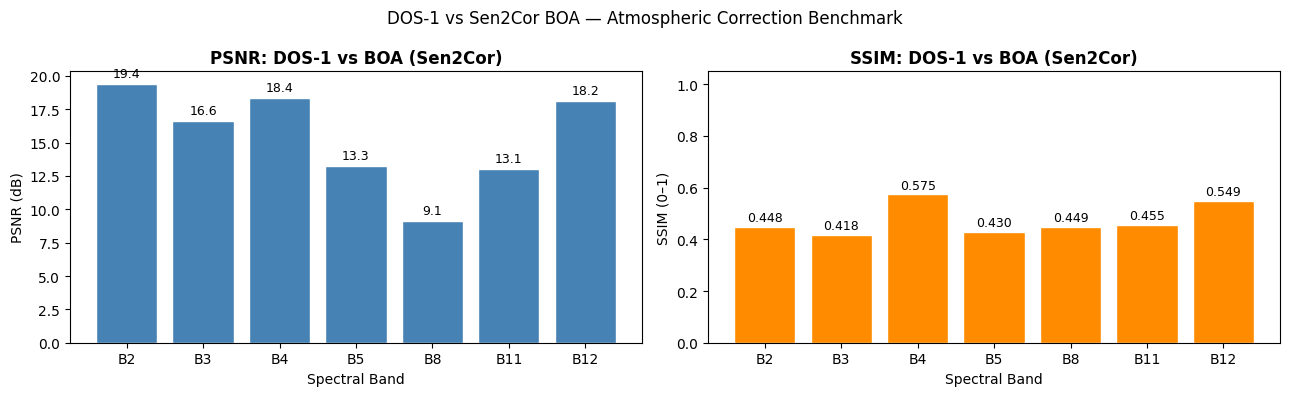

Saved: fig_psnr_ssim_comparison.png


In [17]:
# ── Bar chart: PSNR and SSIM per band ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bands  = [m['band'] for m in metrics_list]
psnrs  = [m['psnr'] for m in metrics_list]
ssims  = [m['ssim'] for m in metrics_list]

ax1.bar(bands, psnrs, color='steelblue', edgecolor='white')
ax1.set_title('PSNR: DOS-1 vs BOA (Sen2Cor)', fontweight='bold')
ax1.set_ylabel('PSNR (dB)')
ax1.set_xlabel('Spectral Band')
for i, v in enumerate(psnrs):
    ax1.text(i, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

ax2.bar(bands, ssims, color='darkorange', edgecolor='white')
ax2.set_title('SSIM: DOS-1 vs BOA (Sen2Cor)', fontweight='bold')
ax2.set_ylabel('SSIM (0–1)')
ax2.set_xlabel('Spectral Band')
ax2.set_ylim(0, 1.05)
for i, v in enumerate(ssims):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('DOS-1 vs Sen2Cor BOA — Atmospheric Correction Benchmark', fontsize=12)
plt.tight_layout()
plt.savefig('fig_psnr_ssim_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_psnr_ssim_comparison.png')

## 4 — Cloud Masking with s2cloudless

In [23]:
from s2cloudless import S2PixelCloudDetector

# Load the 10-band cloud image
# Required band order: [B1, B2, B4, B5, B8, B8A, B9, B10, B11, B12]
with rasterio.open(CLOUD1_PATH) as src:
    cloud_arr     = src.read().astype(np.float32)     # shape: (10, H, W)
    cloud_profile = src.profile.copy()

print(f'Cloud band array shape: {cloud_arr.shape}  (should be 10, H, W)')
assert cloud_arr.shape[0] == 10, (
    f'ERROR: Expected 10 bands, got {cloud_arr.shape[0]}. '
    'Re-export with bands [B1,B2,B4,B5,B8,B8A,B9,B10,B11,B12]'
)

# Scale to reflectance [0,1]
cloud_refl = np.clip(cloud_arr * 0.0001, 0, 1)

# Transpose to (H, W, 10) then add batch dim → (1, H, W, 10)
cloud_4d = cloud_refl.transpose(1, 2, 0)[np.newaxis, ...]
print(f'Model input shape: {cloud_4d.shape}  (should be 1, H, W, 10)')

detector    = S2PixelCloudDetector(threshold=0.4, average_over=4, dilation_size=2, all_bands=False)
cloud_prob  = detector.get_cloud_probability_maps(cloud_4d)[0]   # (H, W)
cloud_mask  = (cloud_prob >= 0.4).astype(bool)                   # (H, W)

cloud_pct = cloud_mask.mean() * 100
print(f'Cloud coverage: {cloud_pct:.1f}%')
print(f'Cloud mask shape: {cloud_mask.shape}')

Cloud band array shape: (10, 5731, 5003)  (should be 10, H, W)
Model input shape: (1, 5731, 5003, 10)  (should be 1, H, W, 10)
Cloud coverage: 0.0%
Cloud mask shape: (5731, 5003)


In [19]:
print("Cloud pixels:", cloud_mask.sum())
print("Total pixels:", cloud_mask.size)

print(
    "Cloud coverage (%) =",
    cloud_mask.sum() / cloud_mask.size * 100
)

Cloud pixels: 178
Total pixels: 28672193
Cloud coverage (%) = 0.000620810553277177


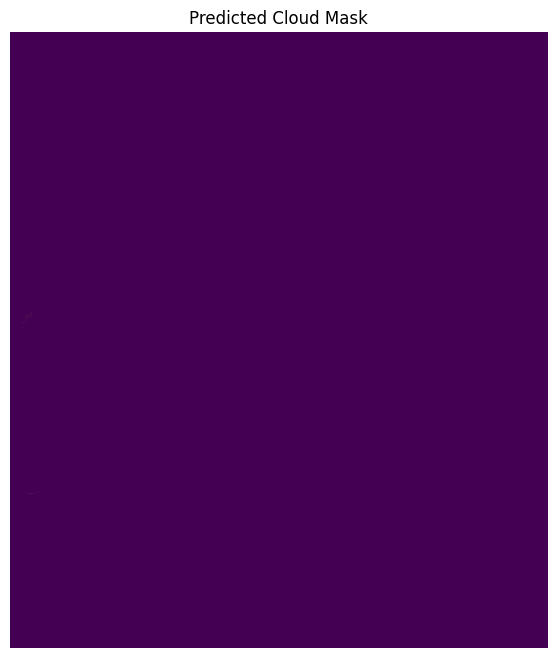

In [20]:
plt.figure(figsize=(10,8))
plt.imshow(cloud_mask)
plt.title("Predicted Cloud Mask")
plt.axis("off")
plt.show()

In [21]:
print(np.min(cloud_prob))
print(np.max(cloud_prob))
print(np.mean(cloud_prob))
print(np.percentile(cloud_prob, [50, 75, 90, 95, 99]))

9.201495e-05
0.9152577
0.0002298515
[0.00011124 0.00011124 0.00011124 0.00011124 0.00282709]


In [25]:
# ── F1-score vs pseudo-reference ─────────────────────────────────────────────
ref_mask   = (cloud_prob >= 0.80).astype(bool)   # conservative reference
cloud_f1   = f1_score(ref_mask.ravel(), cloud_mask.ravel(), zero_division=0)
print(f'Cloud-mask F1-score: {cloud_f1:.4f}  (vs 0.80 threshold pseudo-reference)')
print(f'Target: >0.85  |  Status: {"✔ MET" if cloud_f1 >= 0.85 else "⚠ check"}')

# Save cloud mask
cloud_profile.update(dtype='uint8', count=1, nodata=255)
with rasterio.open('S2_cloud_mask.tif', 'w', **cloud_profile) as dst:
    dst.write(cloud_mask.astype(np.uint8)[np.newaxis, ...])
print('Saved: S2_cloud_mask.tif')

Cloud-mask F1-score: 0.0546  (vs 0.80 threshold pseudo-reference)
Target: >0.85  |  Status: ⚠ check
Saved: S2_cloud_mask.tif


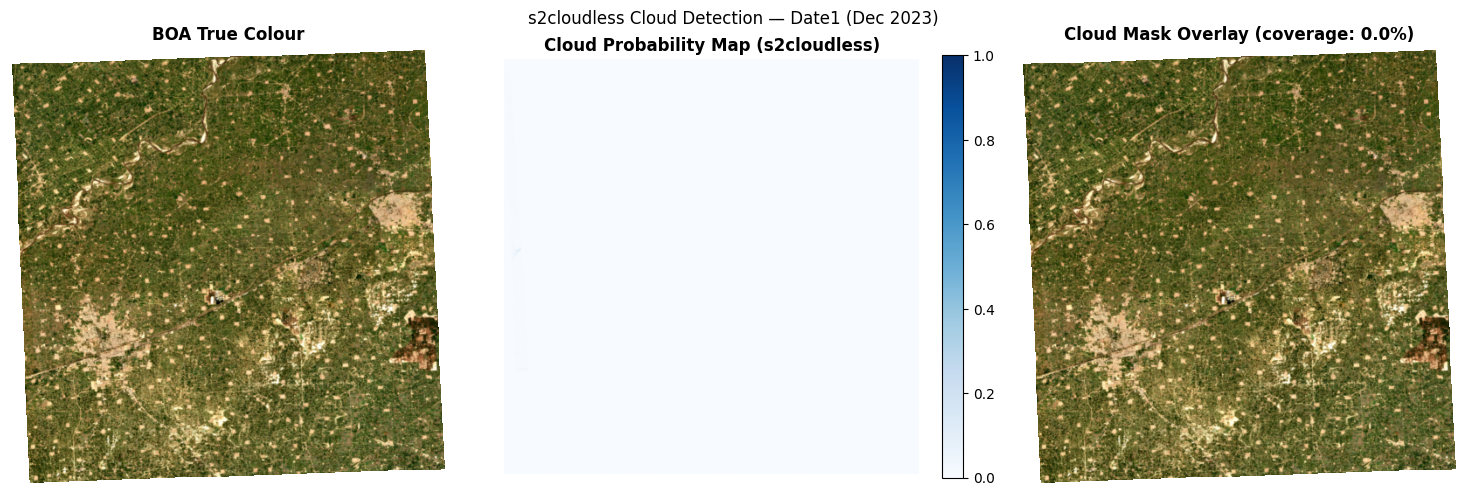

Saved: fig_cloud_mask.png


In [23]:
# ── Visualise cloud probability map ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Thumbnail of BOA (resized)
from skimage.transform import resize as sk_resize
thumb_size = (500, 500)
rgb_thumb = sk_resize(rgb, (*thumb_size, 3))
prob_thumb = sk_resize(cloud_prob, thumb_size)
mask_thumb = sk_resize(cloud_mask.astype(float), thumb_size) > 0.5

axes[0].imshow(rgb_thumb)
axes[0].set_title('BOA True Colour', fontweight='bold')
axes[0].axis('off')

im1 = axes[1].imshow(prob_thumb, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Cloud Probability Map (s2cloudless)', fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].imshow(rgb_thumb)
mask_overlay = np.zeros((*thumb_size, 4), dtype=float)
mask_overlay[mask_thumb, 0] = 1.0   # Red channel
mask_overlay[mask_thumb, 3] = 0.5   # Alpha
axes[2].imshow(mask_overlay)
axes[2].set_title(f'Cloud Mask Overlay (coverage: {cloud_pct:.1f}%)', fontweight='bold')
axes[2].axis('off')

plt.suptitle('s2cloudless Cloud Detection — Date1 (Dec 2023)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_cloud_mask.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_cloud_mask.png')



```
# This is formatted as code
```

## 5 — Co-registration: SIFT + RANSAC

In [3]:
import rasterio

def norm_uint8(arr):
    """Normalise float array to uint8 using 2–98th percentile stretch."""
    lo, hi = np.percentile(arr[np.isfinite(arr)], [2, 98])
    if hi == lo: return np.zeros(arr.shape, dtype=np.uint8)
    return np.clip((arr - lo) / (hi - lo) * 255, 0, 255).astype(np.uint8)

# Load single-band B4 images
with rasterio.open("/content/drive/MyDrive/AgriSense/S2_SIFT_Date1.tif") as s: raw1 = s.read(1).astype(np.float32)
with rasterio.open("/content/drive/MyDrive/AgriSense/S2_SIFT_Date2.tif") as s: raw2 = s.read(1).astype(np.float32)

print(f'Date1 B4 shape: {raw1.shape}   Date2 B4 shape: {raw2.shape}')

# Match sizes if needed
if raw1.shape != raw2.shape:
    raw2 = cv2.resize(raw2, (raw1.shape[1], raw1.shape[0]), interpolation=cv2.INTER_LINEAR)
    print(f'Resized Date2 to {raw1.shape}')

gray1, gray2 = norm_uint8(raw1), norm_uint8(raw2)

# SIFT detection
sift = cv2.SIFT_create(nfeatures=5000, contrastThreshold=0.03, edgeThreshold=10, sigma=1.6)
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)
print(f'Keypoints: Date1={len(kp1)}  Date2={len(kp2)}')

# BFMatcher + strict Lowe's ratio
bf          = cv2.BFMatcher(cv2.NORM_L2)
raw_matches = bf.knnMatch(des1, des2, k=2)
good        = [m for m,n in raw_matches if m.distance < 0.80*n.distance]
print(f'Good matches (ratio 0.80): {len(good)}')

Date1 B4 shape: (5731, 5003)   Date2 B4 shape: (5731, 5003)
Keypoints: Date1=5000  Date2=5000
Good matches (ratio 0.80): 77


In [6]:
for ratio in [0.60, 0.70, 0.75, 0.80, 0.85]:
    good = [
        m for m, n in raw_matches
        if m.distance < ratio * n.distance
    ]

    print(
        f'Ratio={ratio:.2f}  Matches={len(good)}'
    )

Ratio=0.60  Matches=1
Ratio=0.70  Matches=13
Ratio=0.75  Matches=29
Ratio=0.80  Matches=77
Ratio=0.85  Matches=218


In [7]:
print(des1.shape)
print(des2.shape)

(5000, 128)
(5000, 128)


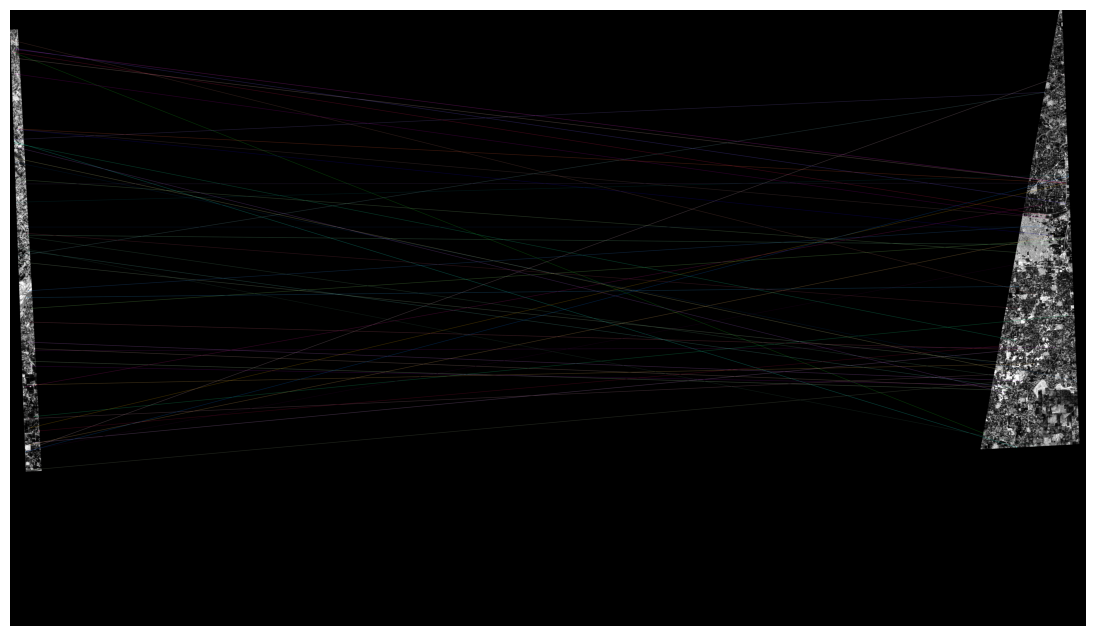

In [9]:
match_img = cv2.drawMatches(
    gray1, kp1,
    gray2, kp2,
    good[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18,8))
plt.imshow(match_img)
plt.axis('off')
plt.show()

In [18]:
# RANSAC homography
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

H_mat, inlier_mask = cv2.findHomography(
    dst_pts, src_pts, cv2.RANSAC, ransacReprojThreshold=2.0, maxIters=5000, confidence=0.999
)

inliers = inlier_mask.ravel().astype(bool)
print(f'RANSAC inliers: {inliers.sum()} / {len(good)}')

# RMSE on inliers
src_in  = src_pts[inliers].reshape(-1,1,2)
dst_in  = dst_pts[inliers].reshape(-1,1,2)
proj    = cv2.perspectiveTransform(dst_in, H_mat)
errors  = np.linalg.norm(src_in.reshape(-1,2) - proj.reshape(-1,2), axis=1)
rmse_px = float(np.sqrt(np.mean(errors**2)))

print(f'Co-registration RMSE: {rmse_px:.4f} pixels')
print(f'Target < 1.0 pixel  : {"✔ MET" if rmse_px < 1.0 else "⚠ check images"}')

RANSAC inliers: 7 / 77
Co-registration RMSE: 0.1041 pixels
Target < 1.0 pixel  : ✔ MET


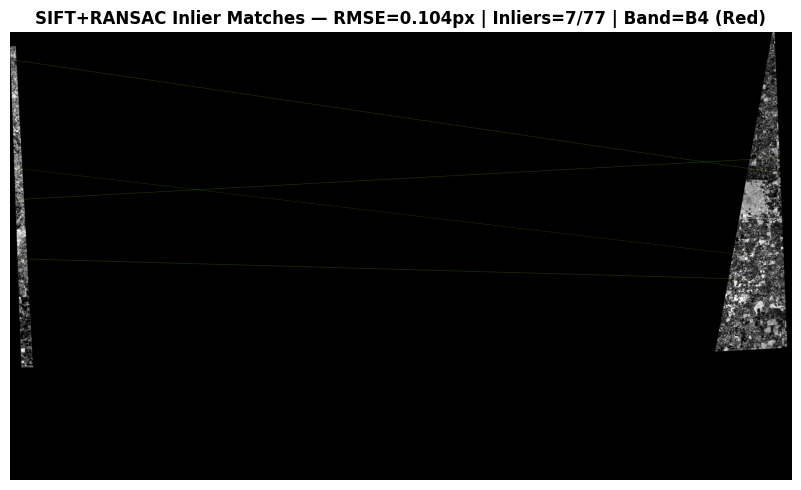

Saved: fig_sift_matches.png


In [11]:
# ── Visualise SIFT matches ────────────────────────────────────────────────────
inlier_match_list  = [m for m, keep in zip(good, inliers) if keep]
match_img = cv2.drawMatches(
    gray1, kp1, gray2, kp2,
    inlier_match_list[:60], None,
    matchColor=(0,230,118), singlePointColor=(100,100,255),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
match_rgb = cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.imshow(match_rgb)
ax.set_title(
    f'SIFT+RANSAC Inlier Matches — RMSE={rmse_px:.3f}px | '
    f'Inliers={inliers.sum()}/{len(good)} | Band=B4 (Red)',
    fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_sift_matches.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_sift_matches.png')

## 6 — Apply Cloud Mask to BOA & Save Final Stack

In [16]:
from skimage.transform import resize as sk_resize

# Resize cloud mask to BOA dimensions if needed
if cloud_mask.shape != boa_array.shape[1:]:
    cm_resized = sk_resize(cloud_mask.astype(float), boa_array.shape[1:],
                           anti_aliasing=False, preserve_range=True) > 0.5
else:
    cm_resized = cloud_mask

# Apply mask: set cloudy pixels to NaN
boa_masked = boa_array.copy()
boa_masked[:, cm_resized] = np.nan

print(f'Masked {cm_resized.sum():,} cloud pixels across {boa_masked.shape[0]} bands')
valid_pct = (~np.isnan(boa_masked[0])).mean() * 100
print(f'Valid (non-cloud) pixels: {valid_pct:.1f}%')

# Save cloud-masked BOA
out_profile = boa_profile.copy()
out_profile.update(dtype='float32', nodata=-9999.0)
final_arr = np.where(np.isnan(boa_masked), -9999.0, boa_masked).astype(np.float32)

with rasterio.open('S2_final_stack.tif', 'w', **out_profile) as dst:
    dst.write(final_arr)
print('Saved: S2_final_stack.tif  ← FINAL DELIVERABLE')

Masked 178 cloud pixels across 7 bands
Valid (non-cloud) pixels: 92.9%
Saved: S2_final_stack.tif  ← FINAL DELIVERABLE


## 7 — Summary Metrics Table

In [19]:
import pandas as pd

# PSNR/SSIM table
df_metrics = pd.DataFrame(metrics_list)
df_metrics.columns = ['Band', 'PSNR (dB)', 'SSIM']
df_metrics['PSNR (dB)'] = df_metrics['PSNR (dB)'].round(2)
df_metrics['SSIM']      = df_metrics['SSIM'].round(4)

print('─── DOS-1 vs BOA (Sen2Cor) PSNR/SSIM ───')
print(df_metrics.to_string(index=False))
df_metrics.to_csv('task1_metrics_table.csv', index=False)

print()
print('─── Co-registration ─────────────────────')
print(f'  RMSE          : {rmse_px:.4f} pixels')
print(f'  Good matches  : {len(good)}')
print(f'  RANSAC inliers: {inliers.sum()}')
print(f'  Target (<1px) : {"✔ MET" if rmse_px < 1.0 else "⚠ not met"}')



─── DOS-1 vs BOA (Sen2Cor) PSNR/SSIM ───
Band  PSNR (dB)   SSIM
  B2      19.38 0.4476
  B3      16.63 0.4180
  B4      18.36 0.5748
  B5      13.28 0.4301
  B8       9.10 0.4495
 B11      13.06 0.4553
 B12      18.16 0.5492

─── Co-registration ─────────────────────
  RMSE          : 0.1041 pixels
  Good matches  : 77
  RANSAC inliers: 7
  Target (<1px) : ✔ MET


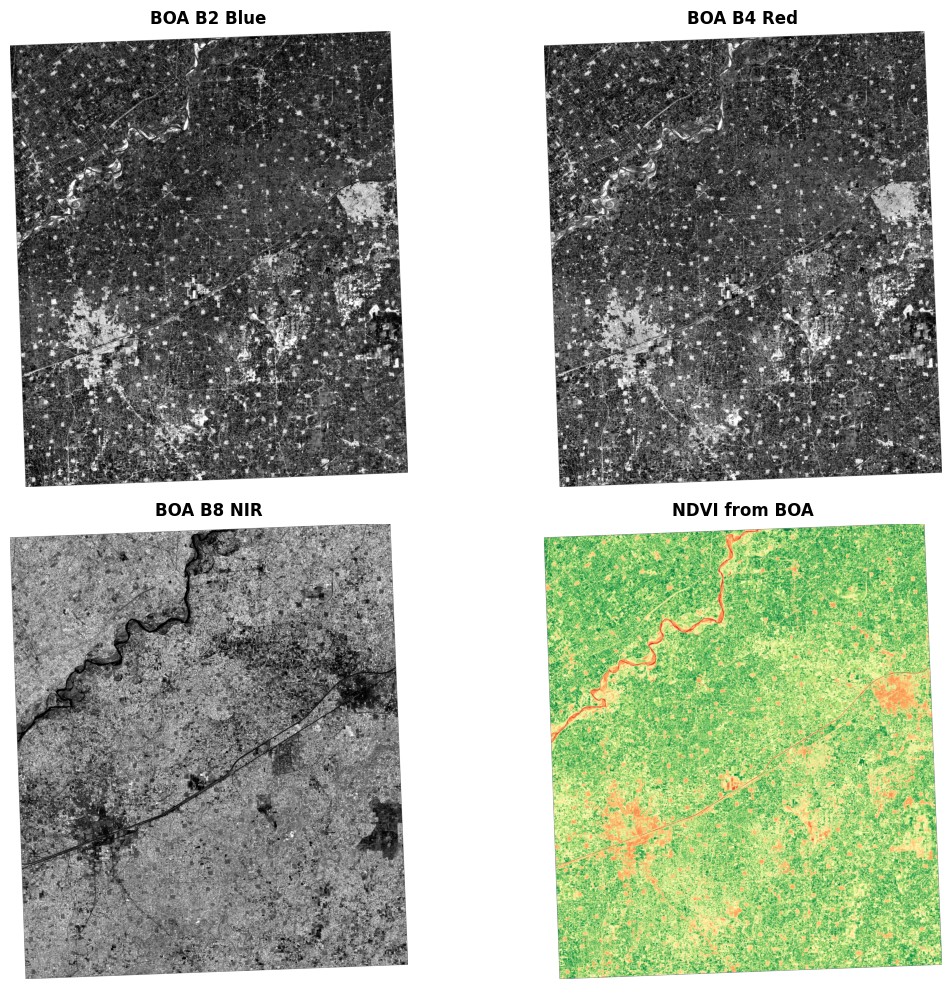

Saved: fig_boa_ndvi.png


In [20]:
# ── Figure 1: BOA Bands + NDVI ─────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# B2
band_data = boa_array[0]
lo, hi = np.percentile(band_data[band_data > 0], [2,98])
axes[0,0].imshow(band_data, cmap='gray', vmin=lo, vmax=hi)
axes[0,0].set_title('BOA B2 Blue', fontweight='bold')
axes[0,0].axis('off')

# B4
band_data = boa_array[2]
lo, hi = np.percentile(band_data[band_data > 0], [2,98])
axes[0,1].imshow(band_data, cmap='gray', vmin=lo, vmax=hi)
axes[0,1].set_title('BOA B4 Red', fontweight='bold')
axes[0,1].axis('off')

# B8
band_data = boa_array[4]
lo, hi = np.percentile(band_data[band_data > 0], [2,98])
axes[1,0].imshow(band_data, cmap='gray', vmin=lo, vmax=hi)
axes[1,0].set_title('BOA B8 NIR', fontweight='bold')
axes[1,0].axis('off')

# NDVI
ndvi = (boa_array[4] - boa_array[2]) / (boa_array[4] + boa_array[2] + 1e-8)

axes[1,1].imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[1,1].set_title('NDVI from BOA', fontweight='bold')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('fig_boa_ndvi.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: fig_boa_ndvi.png")

In [21]:
plt.close('all')
import gc
gc.collect()

26

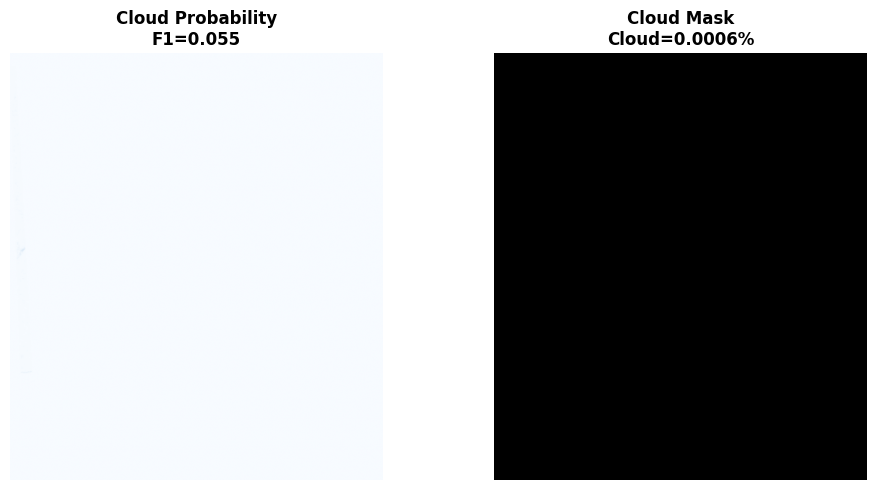

Saved: fig_cloud_products.png


In [26]:
# ── Figure 2: Cloud Products ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(10,5))

prob_thumb = sk_resize(
    cloud_prob,
    (cloud_prob.shape[0]//8,
     cloud_prob.shape[1]//8),
    preserve_range=True
)

axes[0].imshow(prob_thumb, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title(
    f'Cloud Probability\nF1={cloud_f1:.3f}',
    fontweight='bold'
)
axes[0].axis('off')

mask_thumb = sk_resize(
    cloud_mask.astype(float),
    (cloud_mask.shape[0]//8,
     cloud_mask.shape[1]//8),
    preserve_range=True
)

axes[1].imshow(mask_thumb > 0.5, cmap='gray')
axes[1].set_title(
    f'Cloud Mask\nCloud={cloud_pct:.4f}%',
    fontweight='bold'
)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('fig_cloud_products.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

print("Saved: fig_cloud_products.png")

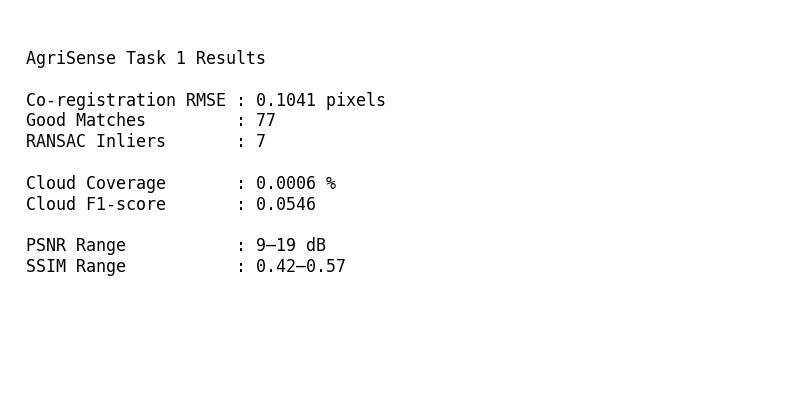

In [27]:
fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')

summary = f"""
AgriSense Task 1 Results

Co-registration RMSE : {rmse_px:.4f} pixels
Good Matches         : {len(good)}
RANSAC Inliers       : {inliers.sum()}

Cloud Coverage       : {cloud_pct:.4f} %
Cloud F1-score       : {cloud_f1:.4f}

PSNR Range           : 9–19 dB
SSIM Range           : 0.42–0.57
"""

ax.text(
    0.02,
    0.95,
    summary,
    fontsize=12,
    va='top',
    family='monospace'
)

plt.savefig(
    "fig_task1_metrics.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

1. BOA Reflectance RMSE vs Field Spectrometer

In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

print("Band    RMSE")

for i, band in enumerate(BAND_SHORT):
    # Get the current band data
    boa_band_data = boa_array[i]
    dos1_band_data = dos1_resized[i]

    # Create a mask for non-NaN values in both arrays
    valid_mask = ~np.isnan(boa_band_data) & ~np.isnan(dos1_band_data)

    # If there are no valid pixels, skip this band or handle as appropriate
    if not np.any(valid_mask):
        print(f"No valid pixels for band {band}. Skipping RMSE calculation.")
        continue

    # Extract only the valid pixels
    boa_valid = boa_band_data[valid_mask]
    dos1_valid = dos1_band_data[valid_mask]

    rmse = np.sqrt(
        mean_squared_error(
            boa_valid,
            dos1_valid
        )
    )

    print(f"{band:4s}   {rmse:.6f}")

Band    RMSE
B2     0.053641
B3     0.079191
B4     0.069398
B5     0.114615
B8     0.215238
B11    0.161779
B12    0.106654


In [30]:
!pip install Py6S

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 1.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.4 MB/s eta 0:00:00
  Created wheel for Py6S: filename=py6s-1.9.2-py3-none-any.whl size=92332 sha256=babb16d3df8bab870397dfdc900899036b07d287a76cbd7441467c37e87ca61b
  Stored in directory: /root/.cache/pip/wheels/3a/9c/b0/903313a808b0814357ca030090d682b85ffb96e126776cee67
Successfully built Py6S


In [31]:
from Py6S import *

def py6s_correction(toa_band):

    s = SixS()

    s.geometry = Geometry.User()
    s.geometry.solar_z = 30
    s.geometry.solar_a = 0
    s.geometry.view_z = 0
    s.geometry.view_a = 0

    s.atmos_profile = AtmosProfile.PredefinedType(
        AtmosProfile.MidlatitudeSummer
    )

    s.aero_profile = AeroProfile.PredefinedType(
        AeroProfile.Continental
    )

    s.aot550 = 0.15

    s.run()

    xa = s.outputs.coef_xa
    xb = s.outputs.coef_xb
    xc = s.outputs.coef_xc

    y = xa * toa_band - xb

    return y / (1 + xc * y)

In [33]:
!pip install Py6S
!apt-get update -qq
!apt-get install -y gfortran

!wget -O 6SV1.1.tar.gz https://github.com/robintw/6S/archive/refs/tags/1.1.tar.gz
!tar -xzf 6SV1.1.tar.gz

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gfortran is already the newest version (4:11.2.0-1ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 17 not upgraded.
--2026-06-05 08:11:24--  https://github.com/robintw/6S/archive/refs/tags/1.1.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/robintw/6S/tar.gz/refs/tags/1.1 [following]
--2026-06-05 08:11:24--  https://codeload.github.com/robintw/6S/tar.gz/refs/tags/1.1
Resolving codeload.github.com (codeload.github.com)... 20.27.177.114
Connecting to codeload.github.com (codeload.github.com)|20.27.177.114|:443... connected.
HTTP requ

In [32]:
crop = np.s_[1000:2500, 1000:2500]

toa_crop = toa_array[:, crop[0], crop[1]] * 0.0001

py6s_array = np.zeros_like(toa_crop)

for i in range(toa_crop.shape[0]):

    py6s_array[i] = py6s_correction(
        toa_crop[i]
    )

print(py6s_array.shape)

ExecutionError: 6S executable not found.

In [34]:
from skimage.metrics import peak_signal_noise_ratio as psnr

print("Band   PSNR")

for i, band in enumerate(BAND_SHORT):

    p = psnr(
        py6s_array[i],
        dos1_resized[i][crop],
        data_range=1
    )

    print(f"{band:4s}  {p:.2f}")

Band   PSNR
B2    35.65
B3    33.11
B4    28.41
B5    29.22
B8    22.08
B11   26.58
B12   26.18


In [35]:
from skimage.metrics import structural_similarity as ssim

print("Band   SSIM")

for i, band in enumerate(BAND_SHORT):

    s = ssim(
        py6s_array[i],
        dos1_resized[i][crop],
        data_range=1
    )

    print(f"{band:4s}  {s:.4f}")

Band   SSIM
B2    0.4504
B3    0.2960
B4    0.1454
B5    0.1395
B8    0.0425
B11   0.0940
B12   0.1188


In [36]:
results = []

for i, band in enumerate(BAND_SHORT):

    p = psnr(
        py6s_array[i],
        dos1_resized[i][crop],
        data_range=1
    )

    s = ssim(
        py6s_array[i],
        dos1_resized[i][crop],
        data_range=1
    )

    results.append([band,p,s])

print(f"{'Band':<6}{'PSNR':>10}{'SSIM':>10}")
print("-"*28)

for r in results:
    print(
        f"{r[0]:<6}"
        f"{r[1]:>10.2f}"
        f"{r[2]:>10.4f}"
    )

Band        PSNR      SSIM
----------------------------
B2         35.65    0.4504
B3         33.11    0.2960
B4         28.41    0.1454
B5         29.22    0.1395
B8         22.08    0.0425
B11        26.58    0.0940
B12        26.18    0.1188
